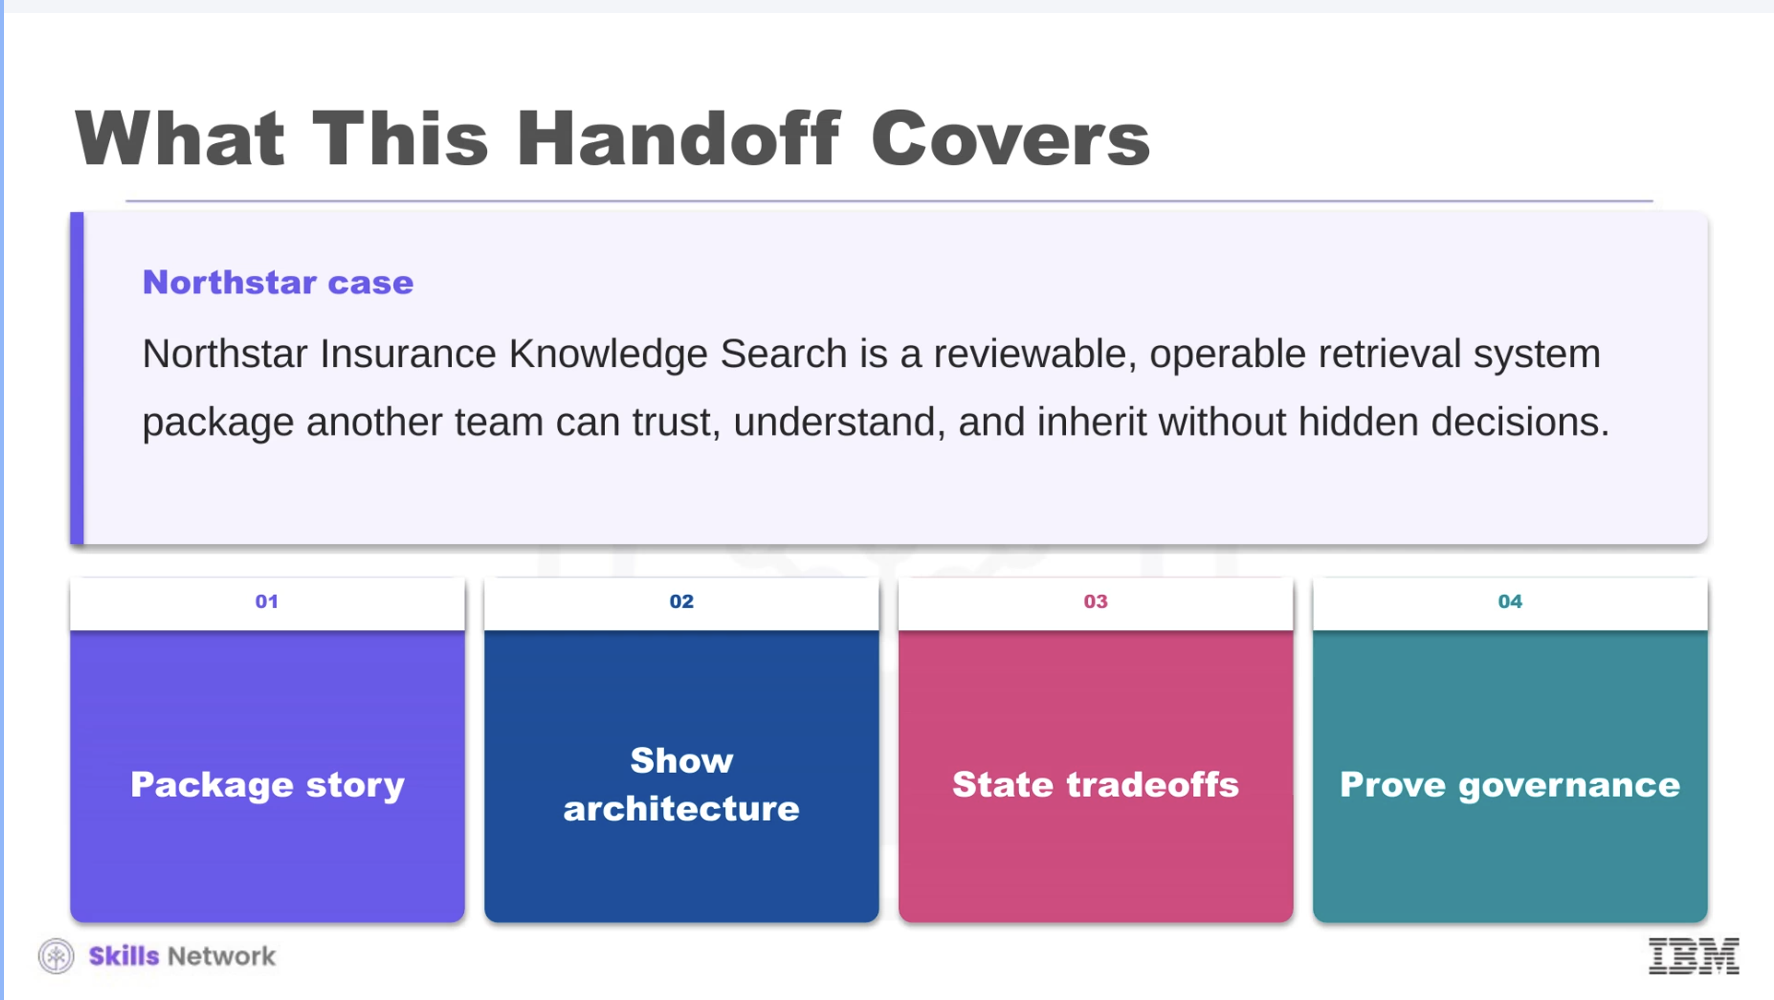
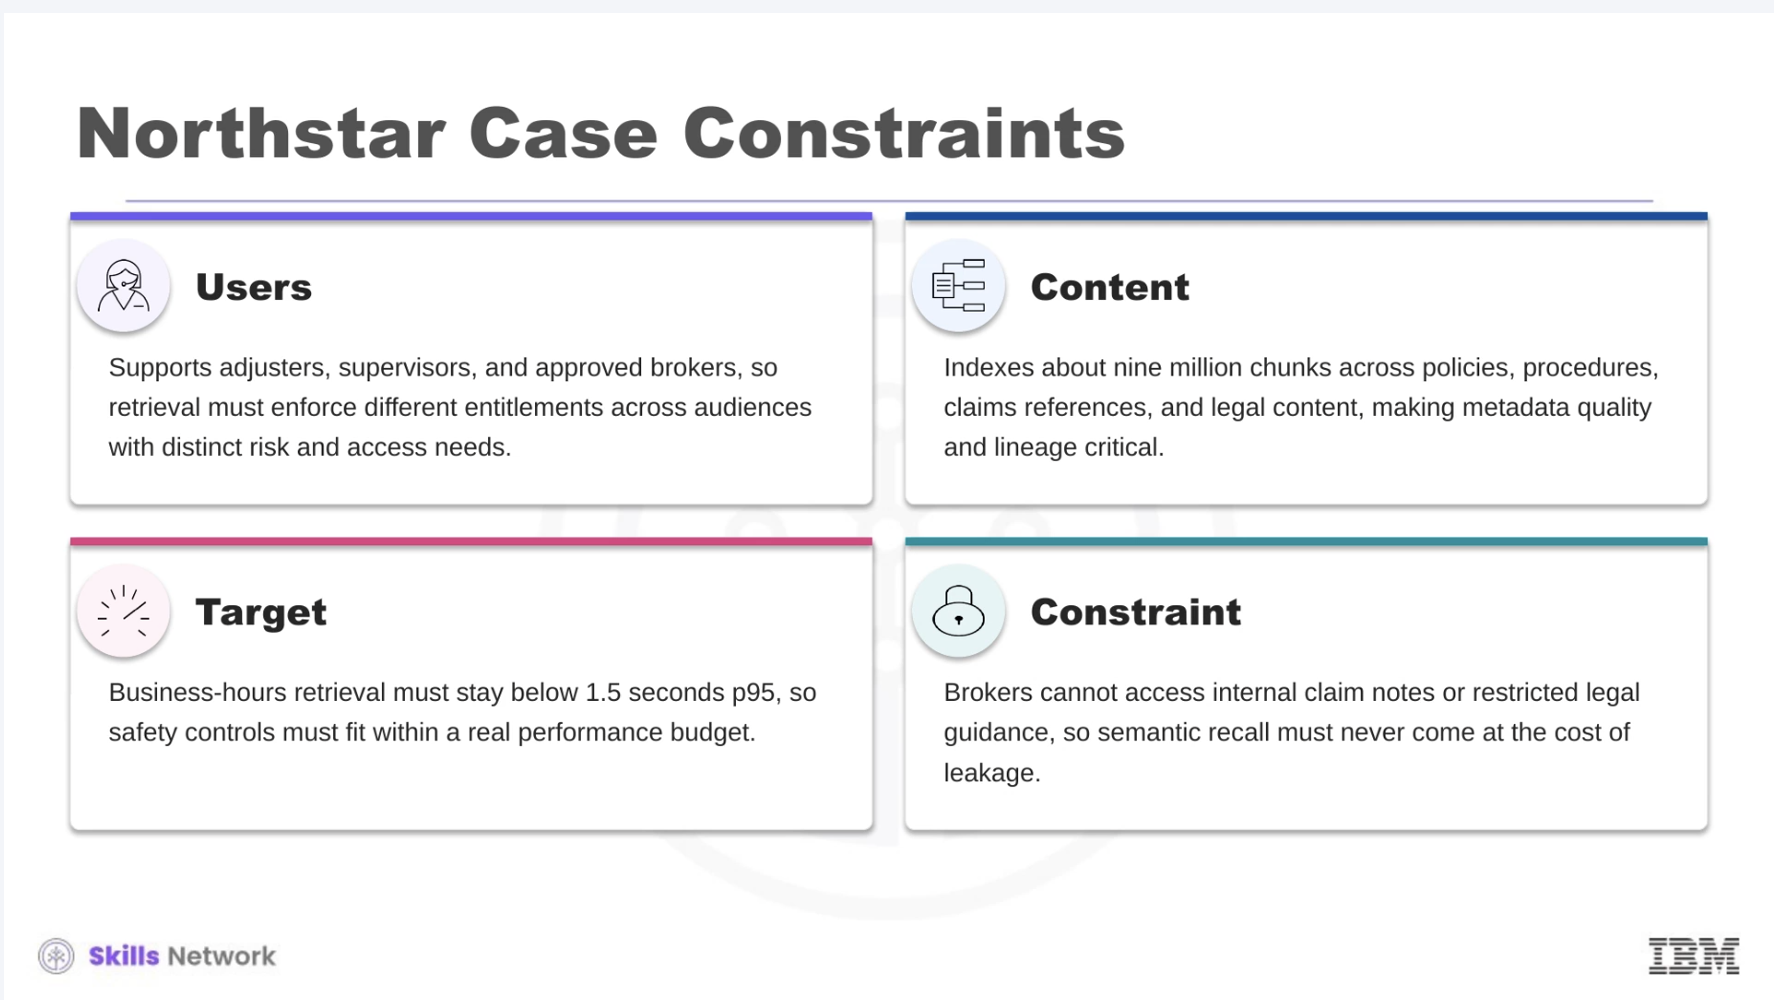
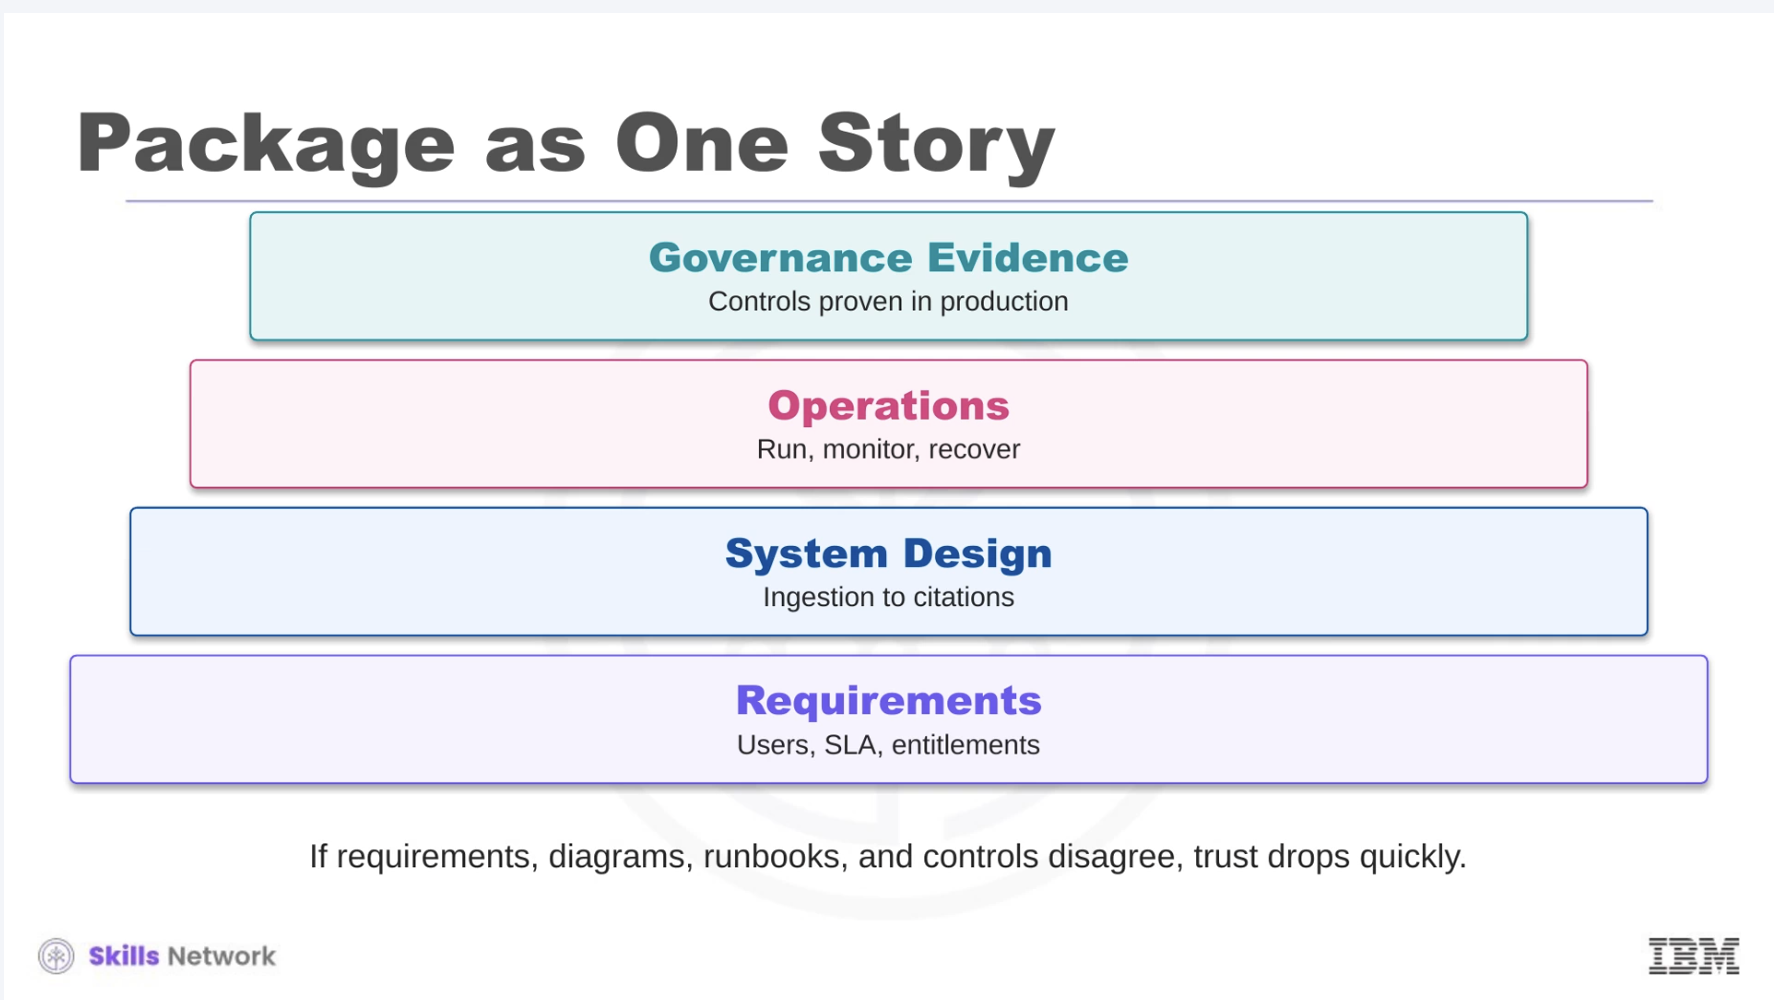
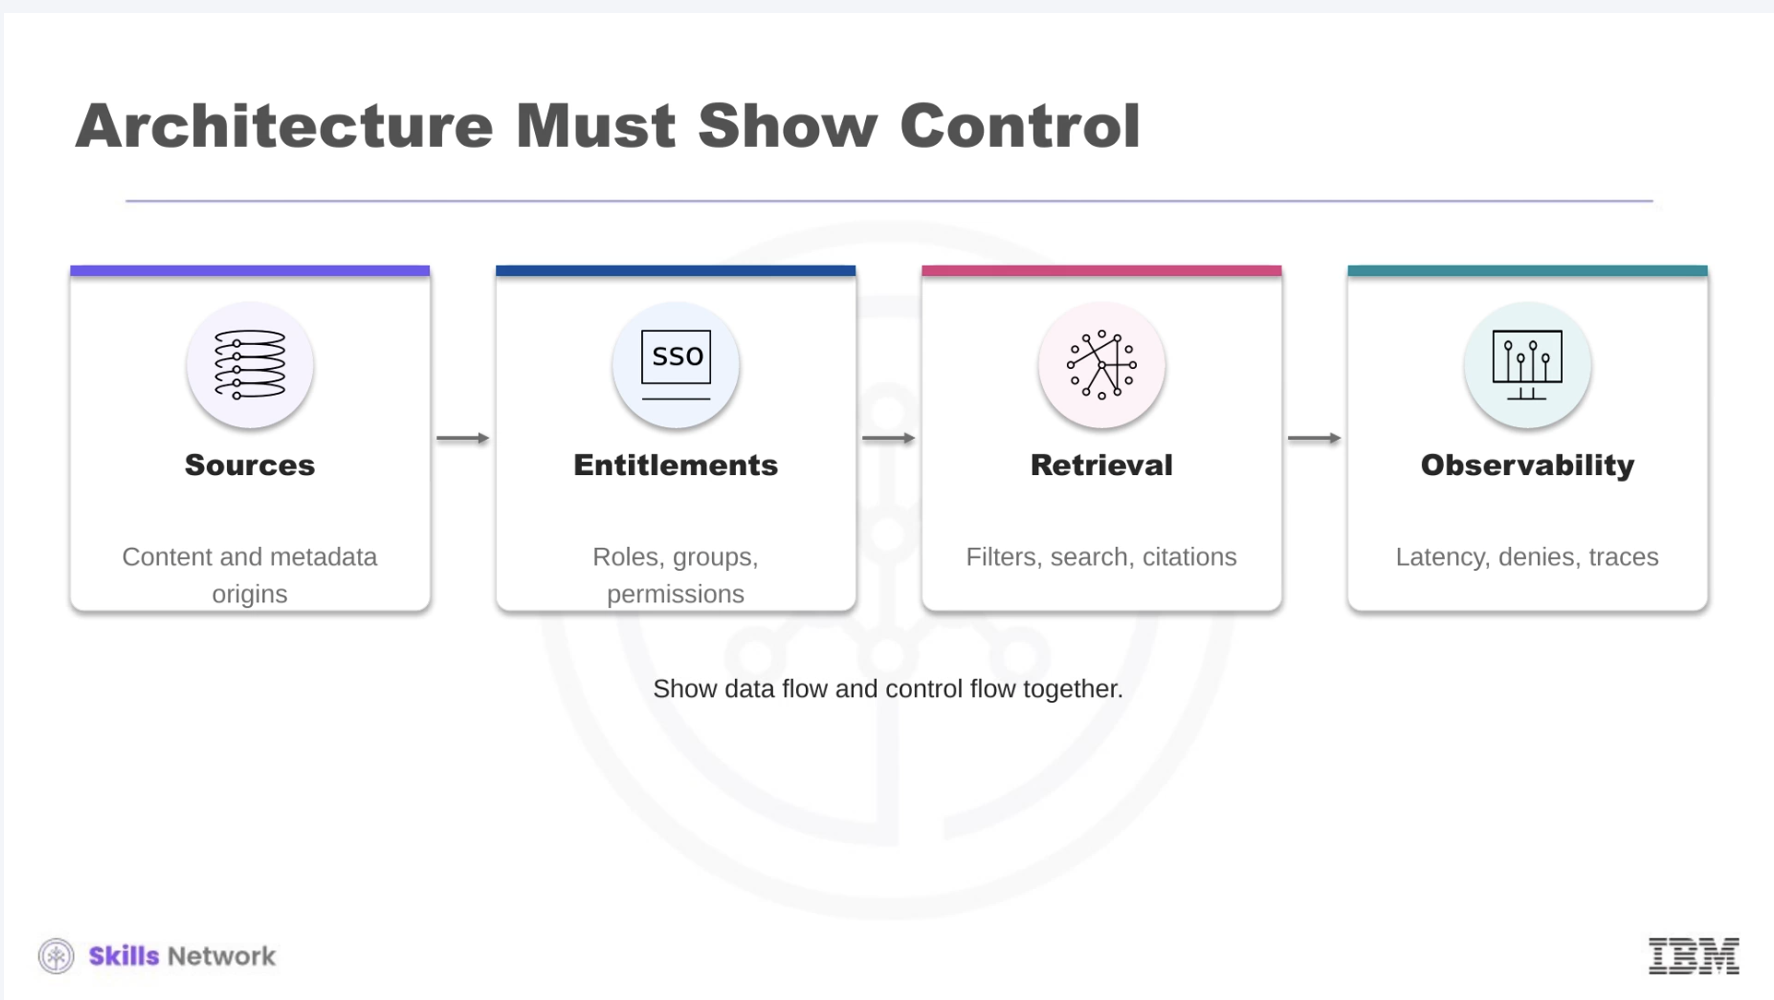
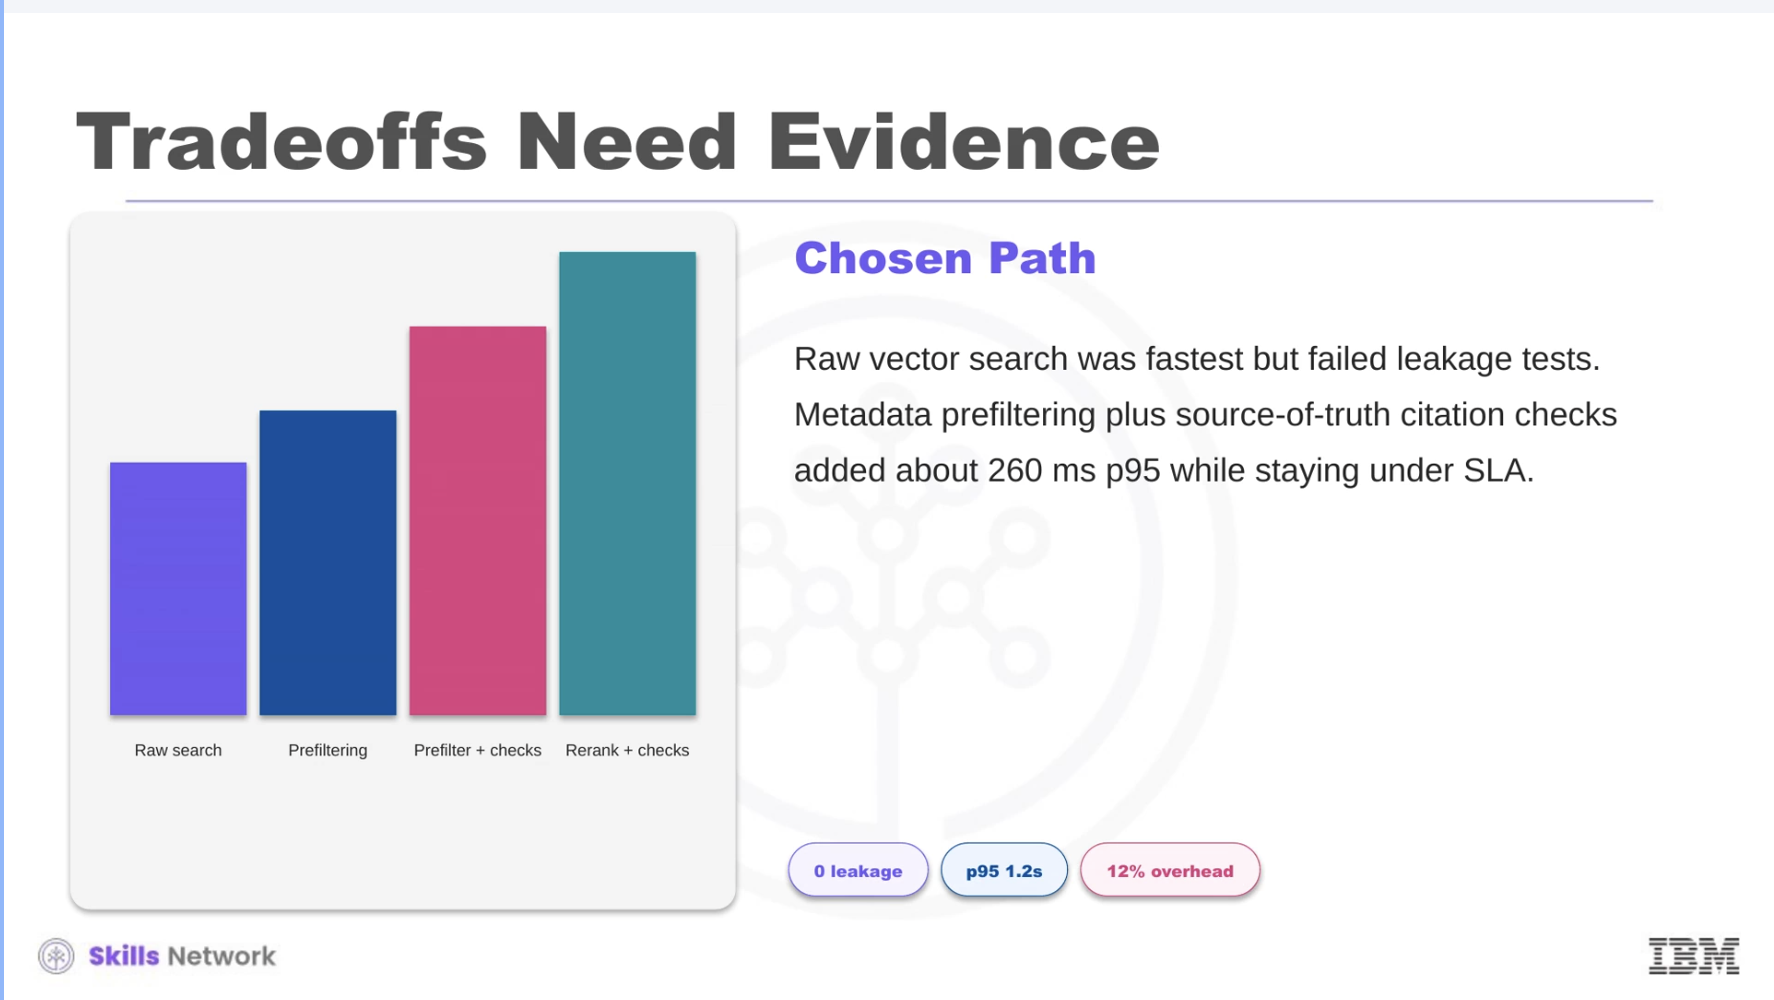
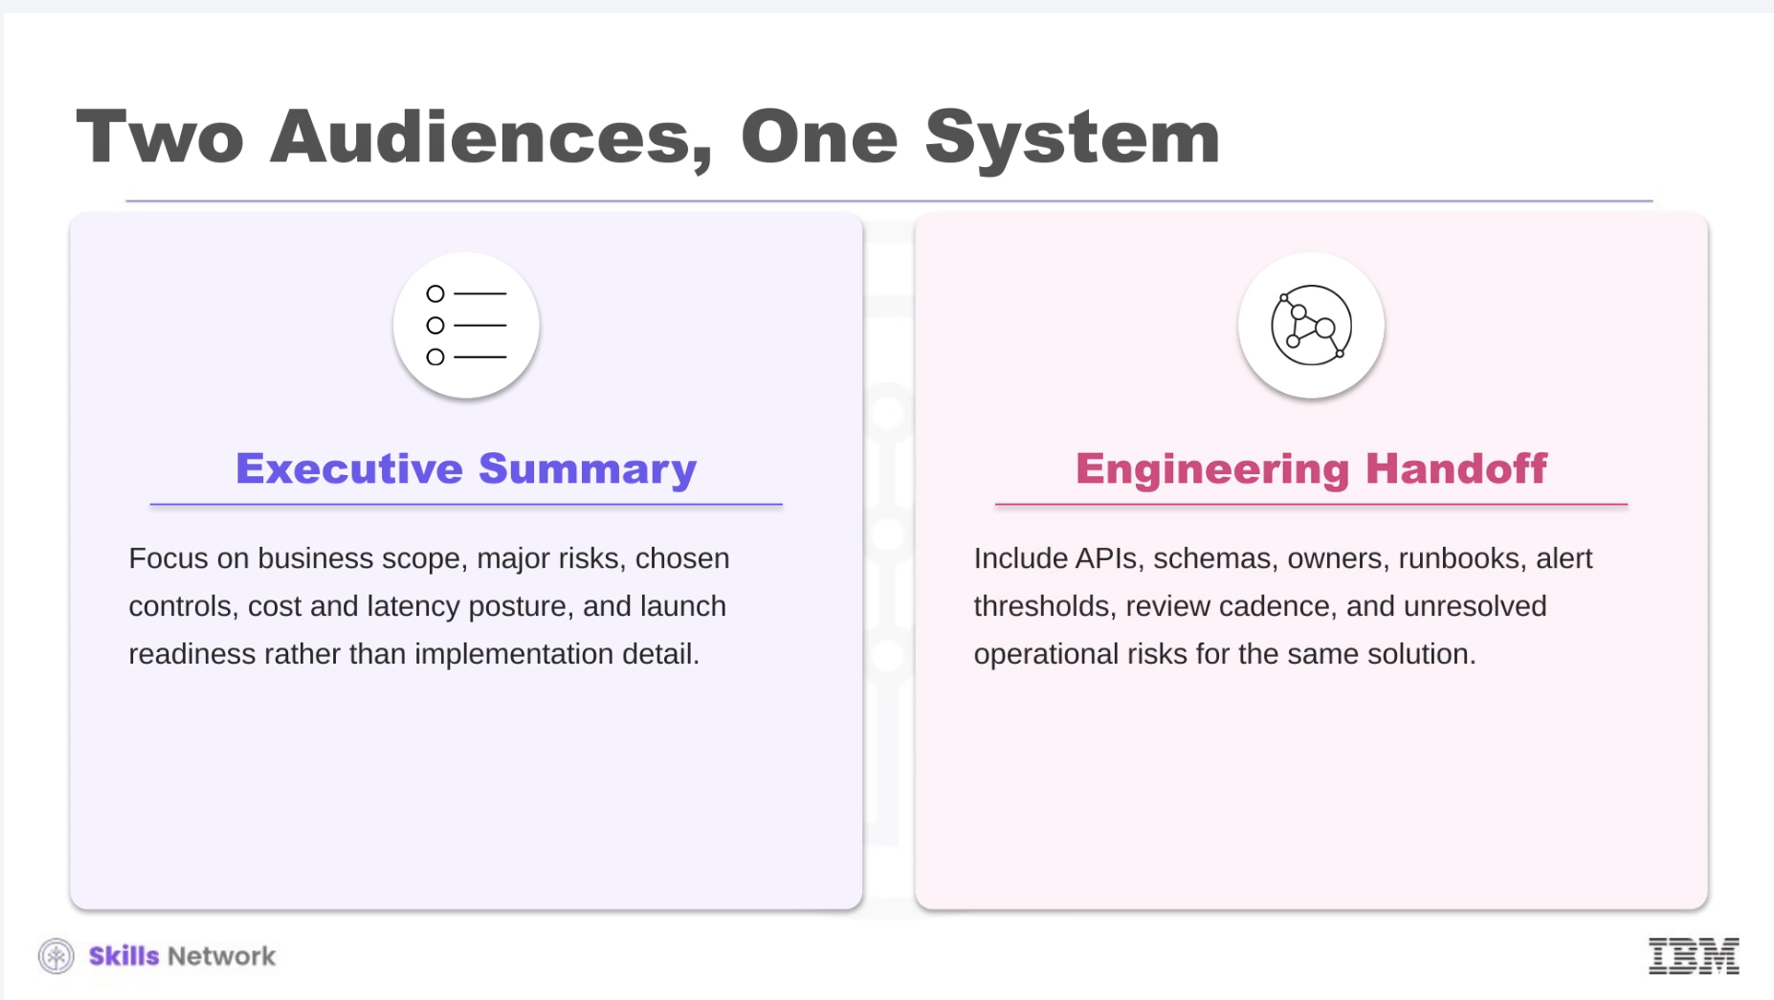
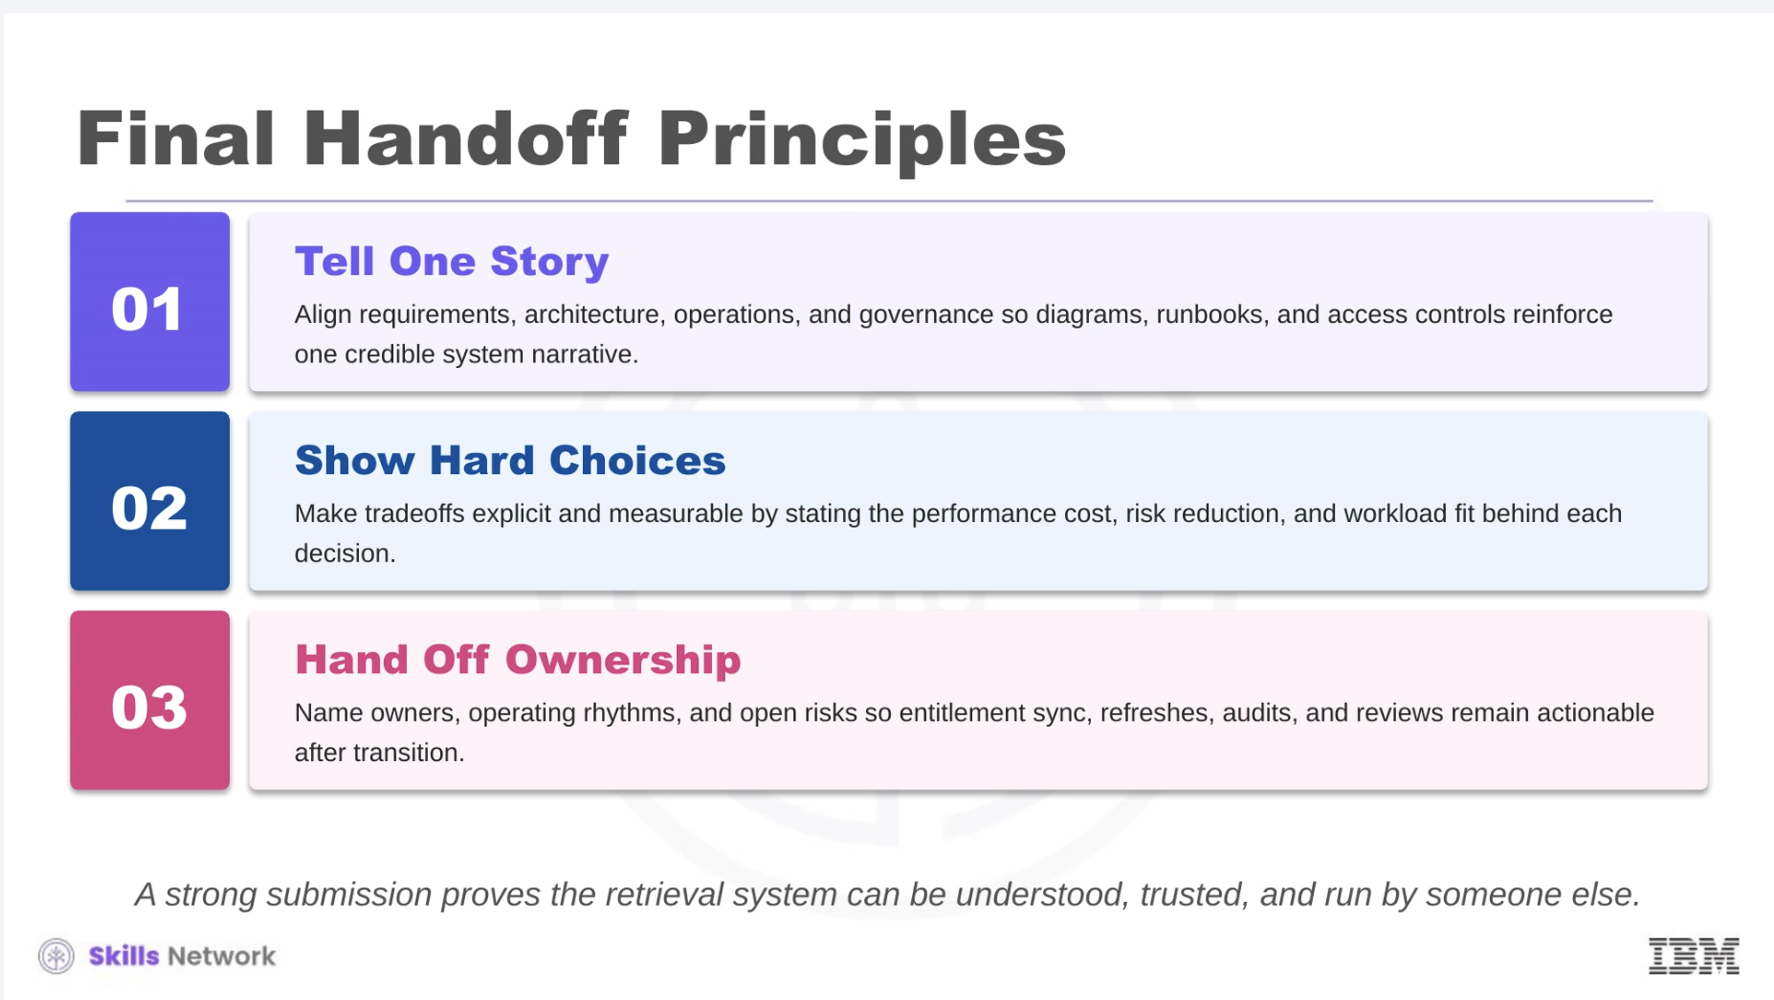


# 📦 Engineering Handoff Requirements for Secure Retrieval Systems

The entire section boils down to one idea:

> 📌 **A secure retrieval system isn't finished when it works. It's finished when another engineer can understand, operate, audit, and modify it without guessing.**

---

## 🔴 1. The final package is evidence, not decoration

Suppose you give someone:

- Architecture diagram
- Some benchmark numbers
- "RBAC implemented"
- "System is secure"

**That is not enough.** A production handoff should provide a **chain of evidence**.

For example, the claim:

```
"We support permission-aware retrieval."
```

Then the documentation should allow someone to trace:

```
User
 ↓
Authentication
 ↓
Tenant/role resolution
 ↓
Permission filters
 ↓
Vector retrieval
 ↓
Reranking
 ↓
Final permission check
 ↓
Response
 ↓
Audit log
```

If the diagram says one thing but the actual implementation does another, the documentation isn't merely outdated — **you have a security problem**.

> 💡 The course specifically says the final artifacts need to **agree with each other**: architecture, evaluation, governance, and runbooks should tell the same story.

---

## 🔴 2. What should actually be inside the handoff?

The course gives this list:

| Artifact | What it answers |
|---|---|
| **Requirements** | What does success mean? |
| **Embedding + metadata schema** | What gets embedded and how is it linked to source? |
| **Vector DB design** | Where/how are vectors stored and filtered? |
| **Index strategy** | Why HNSW/IVF/etc.? |
| **Refresh/delete plan** | How do source changes reach the index? |
| **Evaluation report** | Does retrieval actually work? |
| **Observability** | How do we detect failures/drift? |
| **Security/governance** | How are permissions, logs, reviews handled? |
| **Architecture diagram** | How does the whole system flow? |
| **Handoff notes** | What does the next engineer need to know? |

This is basically the final documentation package for my RAG system.

### The important connection

Notice how this maps almost perfectly to everything we've been studying:

```
Requirements
     ↓
Data + Metadata
     ↓
Embedding / Chunking
     ↓
Vector Store + Index
     ↓
Retrieval + Filtering
     ↓
Reranking
     ↓
Response
```

And around it:

```
Refresh / Delete
Monitoring
Security
Audit
Evaluation
Rollback
```

> 💡 So this chapter isn't really introducing a new retrieval algorithm. It's teaching how to **package everything I've learned into a production system**.

---

## 🔴 3. Five things MUST be explicit

The course emphasizes five things:

1. Assumptions
2. Owners
3. Known risks
4. Validation steps
5. Review cadence

### 3.1 Assumptions

What does the architecture assume? Example:

```
ACL updates arrive within 5 minutes.
```

That's an assumption. If ACL updates actually take 2 hours, the "secure retrieval" guarantee is **broken**.

The course gives examples such as:

- stable document IDs
- available ACL metadata
- delete-event freshness
- explicit tenant isolation mechanisms

### 3.2 Owners

Someone must own each component. For example:

| Component | Owner |
|---|---|
| Embedding pipeline | Data/ML engineer |
| Vector DB/index | Retrieval engineer |
| Permission enforcement | Security/backend engineer |
| ACL synchronization | IAM/data pipeline owner |
| Audit logs | Security/compliance |
| Monitoring | Platform/SRE |

**Why?** Because saying:

```
"The system has permission synchronization"
```

is useless during an incident. Someone needs to know:

```
Who fixes it?
```

The handoff explicitly calls for ownership of ingestion, vector storage, retrieval/permission enforcement, ACL integration, audit logs, and dashboards.

---

## 🔴 4. Known risks

Don't write:

```
"System is secure."
```

Write:

| Field | Value |
|---|---|
| **Risk** | ACL update delayed |
| **Impact** | Unauthorized document may remain retrievable |
| **Detection** | Permission-deny anomaly + ACL freshness monitor |
| **Mitigation** | Query-time permission validation |
| **Owner** | Retrieval security owner |

The course specifically calls out risks such as:

- permission leakage
- stale vectors
- failed deletes
- evaluation blind spots
- documentation/architecture drift

> 📌 This is very important for my security project.

---

## 🔴 5. Validation steps

This is basically:

> 💡 **Don't just say your control exists. Prove it.**

For example, to test tenant isolation:

### Test 1

Create:

```
Tenant A
 ├── Doc A1
 └── Doc A2

Tenant B
 ├── Doc B1
 └── Doc B2
```

Query as Tenant A.

```
Expected:
A1
A2

Never:
B1
B2
```

Then **change permissions** and verify the retrieval result changes.

Then **delete a document** and verify:

```
source deleted
      ↓
vector deleted
      ↓
search no longer returns it
```

The course's validation checklist explicitly includes:

- mixed-tenant permissions
- ACL updates
- deletion verification
- evaluation reruns
- audit-log inspection
- dashboard checks

---

## 🔴 6. Review cadence

"Review regularly" is meaningless. Instead:

| Review | Cadence |
|---|---|
| Dashboard | weekly |
| Access review | monthly |
| Control review | quarterly |
| Architecture | every major release |

And operational events should have **runbooks**:

```
Delete failure
     ↓
Delete replay runbook

Bad index
     ↓
Rollback runbook

Permission sync failure
     ↓
Permission recovery runbook
```

That's the difference between:

```
"We have a system"
```

and

```
"We have an operable production system."
```

---

## 🔴 7. Security documentation needs to be specific

This is one of the most important parts of the chapter.

Don't write:

```
"RBAC enforced."
```

That's almost worthless. Instead:

> Retrieval service applies **source-derived allowlist filters** before returning candidates, **denial decisions are logged with reason codes**, and **permission state is revalidated** when updates arrive.

The course explicitly contrasts vague claims with **mechanism-level statements** like this.

Same thing for monitoring. Don't say:

```
"We monitor the system."
```

Say:

```
Monitor:
- p95 latency
- recall@k
- empty-result rate
- permission-deny rate
- stale-index lag
- delete propagation failures
```

That is **measurable**.

| | ❌ Vague claim | ✅ Mechanism-level statement |
|---|---|---|
| **Security** | "RBAC enforced." | Source-derived allowlist filters before returning candidates + denials logged with reason codes + permission state revalidated on updates |
| **Monitoring** | "We monitor the system." | p95 latency, recall@k, empty-result rate, permission-deny rate, stale-index lag, delete propagation failures |

---

## 🔴 8. Architecture consistency

This is probably **the most important concept of this final section**.

Imagine the documentation says:

```
User
 ↓
Permission Filter
 ↓
Vector Search
 ↓
Reranker
```

But the actual implementation does:

```
User
 ↓
Vector Search
 ↓
Reranker
 ↓
Permission Filter
```

Those are **not equivalent security architectures**. The second one may allow unauthorized content to enter the candidate pipeline.

| | Documented | Actually deployed |
|---|---|---|
| Order | Permission filter → Vector search → Reranker | Vector search → Reranker → Permission filter |
| Style | Pre-filtering | Post-filtering |
| Unauthorized content in candidate pipeline? | No | **Possibly yes** |

> 📌 The course explicitly says that if prose claims pre-filtering while the deployed path removes unauthorized chunks only after retrieval, that's a **trust problem, not just a documentation problem**.

This connects directly to what we learned earlier about **pre-filtering vs post-filtering**.

---

## 🟡 9. Threat model

The course marks this as **optional enrichment**. For my project, though, I'd definitely understand it.

A threat model asks:

```
How could someone misuse or break my retrieval system?
```

Examples:

### Cross-tenant leakage

```
Tenant A query
      ↓
Buggy filter
      ↓
Tenant B document
```

### Stale permission

```
User loses access
      ↓
ACL changes
      ↓
Vector metadata not updated
      ↓
Old document still retrieved
```

### Metadata leakage

```
Vector result
      ↓
Internal metadata accidentally exposed
```

### Audit-log leakage

```
Sensitive user query
      ↓
Raw query logged
      ↓
Logs become a second sensitive dataset
```

The course specifically highlights:

- cross-tenant leakage
- stale permission replay
- over-broad metadata filters
- sensitive information exposure through logs/embeddings

---

## 🟢 10. What you DON'T need to memorize

You do **not** need to memorize the exact handoff table or every sentence. You need the mental model:

```
Production RAG
      │
      ├── Requirements
      ├── Data / Metadata
      ├── Retrieval
      ├── Evaluation
      ├── Security
      ├── Operations
      ├── Monitoring
      ├── Audit
      └── Rollback
```

And for **every component** ask:

1. What is it?
2. Who owns it?
3. What can go wrong?
4. How do I detect it?
5. How do I validate it?
6. How do I recover?

> 💡 That's the real lesson.

---

## 🔥 11. How this connects to MY Secure RAG

This section is basically telling me what my eventual project documentation should look like.

My architecture could eventually have:

```
                    ┌─────────────────┐
                    │   User Query    │
                    └────────┬────────┘
                             ↓
                    Authentication
                             ↓
                 Tenant / Permission
                     Resolution
                             ↓
                ┌─────────────────────┐
                │ Retrieval Service   │
                │                     │
                │ Server-side filters │
                └──────────┬──────────┘
                           ↓
                     Vector Search
                           ↓
                       Reranker
                           ↓
                 Permission Re-check
                           ↓
                   ┌──────────────┐
                   │ Police LLM   │
                   │ (optional    │
                   │ safety layer)│
                   └──────┬───────┘
                          ↓
                    Main LLM
                          ↓
                       Answer
```

And alongside it:

```
Source DB/CMS
     ↓
CDC / Sync
     ↓
Chunking + Embedding
     ↓
Vector DB

        + Audit Logs
        + Monitoring
        + Evaluation
        + Rollback
```

> ⚠️ **Important:** as discussed earlier, my "police LLM" should **not** be the final authorization mechanism. Deterministic permission enforcement must remain **structural**. The LLM can provide an additional safety/validation layer.

---

## 🧠 Final takeaway

The whole chapter can be compressed into one sentence:

> 📌 **A production secure-RAG system must be not only functional, but explainable, testable, auditable, operable, and recoverable.**

And the final package is **the evidence** proving all of that.

This also means I've essentially reached the end of the course's retrieval-engineering/security foundation: the next logical step is taking these principles and **designing my own Secure RAG architecture** rather than learning another isolated retrieval concept.